# Wine Quality Classification

Predicting whether a wine is **Low**, **Medium**, or **High** quality based on its physicochemical measurements.

**Dataset:** UCI Wine Quality Dataset (Cortez et al., 2009), containing red and white wine samples.

This notebook covers the complete workflow: data preprocessing, feature engineering, model training, and evaluation, and exports the final model used by the API.


## 1. Load the data

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RED = "../../data/raw/winequality-red.csv"
WHITE = "../../data/raw/winequality-white.csv"

red = pd.read_csv(RED, sep=";")
white = pd.read_csv(WHITE, sep=";")

print("red:  ", red.shape)
print("white:", white.shape)


red:   (1599, 12)
white: (4898, 12)


The two datasets have the same columns, so they can be combined into a single dataset. Before merging them, a `wine_type` column is added to identify whether each sample comes from red or white wine, so this information is preserved after merging.

## 2. Explore the data

In [15]:
red["wine_type"] = 0
white["wine_type"] = 1

df = pd.concat([red, white], ignore_index=True)

df = df.rename(columns={
    "fixed acidity": "fixed_acidity",
    "volatile acidity": "volatile_acidity",
    "citric acid": "citric_acid",
    "residual sugar": "residual_sugar",
    "free sulfur dioxide": "free_sulfur_dioxide",
    "total sulfur dioxide": "total_sulfur_dioxide",
    "pH": "ph",
})

df.head()


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


In [16]:
df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   ph                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  wine_type             6497 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 660.0 KB


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,quality,wine_type
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378,0.753886
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255,0.430779
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000,0.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000,1.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000,1.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000,1.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000,1.000000


### Missing values

In [17]:
print(df.isnull().sum())
print("\ntotal missing values:", df.isnull().sum().sum())


fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
ph                      0
sulphates               0
alcohol                 0
quality                 0
wine_type               0
dtype: int64

total missing values: 0


No missing values were found in the dataset, so no values needed to be filled or removed.

### Duplicate rows

In [18]:
print("duplicate rows:", df.duplicated().sum())


duplicate rows: 1177


Duplicate rows were found in the dataset, so they need to be removed.

In [19]:
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)

print(f"{before} rows -> {len(df)} rows ({before - len(df)} duplicates removed)")


6497 rows -> 5320 rows (1177 duplicates removed)


## 3. The target column

### Feature Engineering Technique 1: Binning

Quality scores range from 3 to 9, but the classes are highly unbalanced, with only a few wines receiving scores of 3 or 9. With very few samples in a class, the model may not learn that class effectively.

Therefore, the quality scores are grouped into three classes using the median score of 6 as the main split point:

| Class | Quality scores | Meaning |
|---|---|---|
| Low | 3, 4, 5 | below the median rating |
| Medium | 6 | at the median rating |
| High | 7, 8, 9 | above the median rating |


In [20]:
QUALITY_MAP = {3: "Low", 4: "Low", 5: "Low", 6: "Medium", 7: "High", 8: "High", 9: "High"}
CLASS_ORDER = ["Low", "Medium", "High"]

df["quality_class"] = df["quality"].map(QUALITY_MAP)

counts = df["quality_class"].value_counts().reindex(CLASS_ORDER)
print(counts)
print("\nas a percentage:")
print((counts / len(df) * 100).round(1))


quality_class
Low       1988
Medium    2323
High      1009
Name: count, dtype: int64

as a percentage:
quality_class
Low       37.4
Medium    43.7
High      19.0
Name: count, dtype: float64


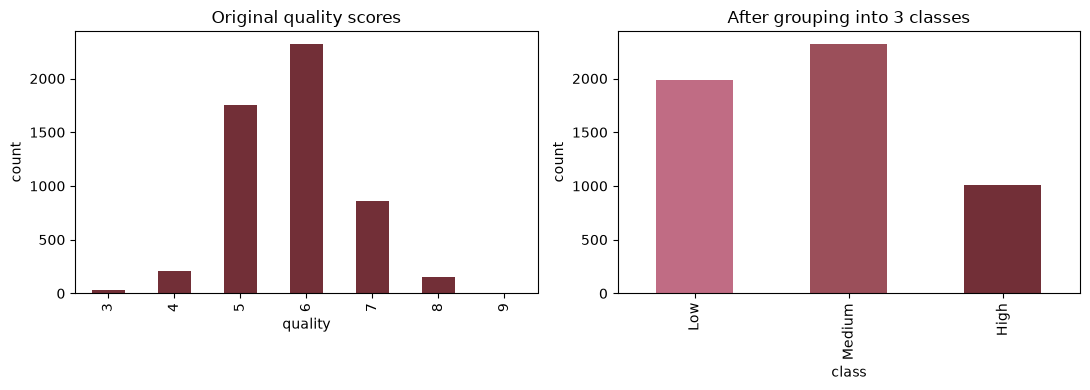

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

df["quality"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="#722F37")
axes[0].set_title("Original quality scores")
axes[0].set_xlabel("quality")
axes[0].set_ylabel("count")

counts.plot(kind="bar", ax=axes[1], color=["#C06C84", "#9B4F5A", "#722F37"])
axes[1].set_title("After grouping into 3 classes")
axes[1].set_xlabel("class")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()


## 4. Do the measurements relate to quality?

In [22]:
correlations = df.corr(numeric_only=True)["quality"].drop(["quality", "quality_class"], errors="ignore")
correlations.sort_values(ascending=False)


alcohol                 0.469422
wine_type               0.114809
citric_acid             0.097954
free_sulfur_dioxide     0.054002
sulphates               0.041884
ph                      0.039733
total_sulfur_dioxide   -0.050296
residual_sugar         -0.056830
fixed_acidity          -0.080092
chlorides              -0.202137
volatile_acidity       -0.265205
density                -0.326434
Name: quality, dtype: float64

`alcohol` has the strongest positive correlation with quality, and `volatile_acidity` the strongest negative one. Both make sense: volatile acidity is acetic acid, which is what makes wine taste of vinegar.

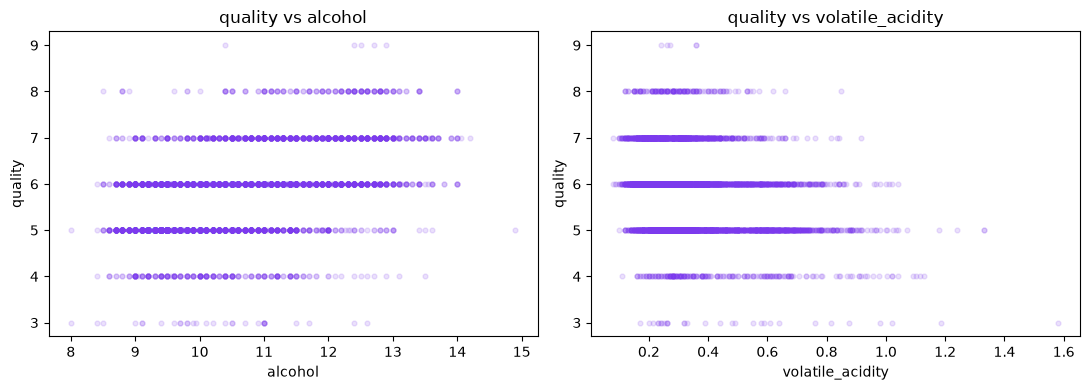

,alcohol,volatile_acidity,density
quality_class,,,
Low,9.912909,0.402915,0.995638
Medium,10.649060,0.315626,0.994377
High,11.573175,0.293930,0.992727


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, col in zip(axes, ["alcohol", "volatile_acidity"]):
    ax.scatter(df[col], df["quality"], alpha=0.15, s=12, color="#7c3aed")
    ax.set_xlabel(col)
    ax.set_ylabel("quality")
    ax.set_title(f"quality vs {col}")

plt.tight_layout()
plt.show()

df.groupby("quality_class")[["alcohol", "volatile_acidity", "density"]].mean().reindex(CLASS_ORDER)


High quality wines have noticeably more alcohol and less volatile acidity on average. The scatter plots are hard to read because quality only takes whole number values, so the points sit in horizontal lines.

## 5. Feature Engineering

This project applies **six** feature engineering techniques in total, each labelled explicitly:

1. **Binning** — the `quality` score grouped into Low/Medium/High (Section 3, above).
2. **Feature creation** — four new domain-derived chemistry features.
3. **Outlier treatment** — IQR-based clipping on skewed columns.
4. **Encoding categorical variables** — `wine_type` encoded as binary (0/1) at load time (Section 2).
5. **Feature scaling / standardization** — applied inside the modelling pipeline (Section 6).
6. **Feature selection (leakage prevention)** — `quality` itself is deliberately excluded from the model inputs.


### Technique 2: Feature creation (domain-derived features)

In [24]:
df["total_acidity"] = df["fixed_acidity"] + df["volatile_acidity"] + df["citric_acid"]
df["bound_sulfur_dioxide"] = df["total_sulfur_dioxide"] - df["free_sulfur_dioxide"]

df["free_sulfur_ratio"] = np.where(
    df["total_sulfur_dioxide"] == 0,
    0,
    df["free_sulfur_dioxide"] / df["total_sulfur_dioxide"],
)

df["alcohol_density_ratio"] = df["alcohol"] / df["density"]


### Technique 3: Outlier treatment (IQR clipping)

`residual_sugar` and `chlorides` are the two most heavily skewed measurements. Extreme values are clipped to the IQR bounds rather than dropped, so no rows are lost.

In [25]:
for col in ["residual_sugar", "chlorides"]:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_clipped = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower, upper)
    print(f"{col}: clipped {n_clipped} outlier values to [{lower:.2f}, {upper:.2f}]")


residual_sugar: clipped 141 outlier values to [-6.75, 16.05]
chlorides: clipped 237 outlier values to [-0.00, 0.11]


### Technique 4 & 6: Encoding and feature selection

`wine_type` was already encoded as a binary flag (0 = red, 1 = white) when the two files were loaded in Section 2 — listed here for completeness as the categorical-encoding technique.

`quality` is intentionally left out of the model inputs below: the target `quality_class` was calculated directly from `quality`, so leaving it in would be giving the model the answer. It would score close to 100% and mean nothing.

In [26]:
FEATURES = [
    "fixed_acidity", "volatile_acidity", "citric_acid", "residual_sugar",
    "chlorides", "free_sulfur_dioxide", "total_sulfur_dioxide", "density",
    "ph", "sulphates", "alcohol", "wine_type",
    "total_acidity", "bound_sulfur_dioxide", "free_sulfur_ratio",
    "alcohol_density_ratio",
]

X = df[FEATURES]
y = df["quality_class"]


### Train / test split

`stratify=y` keeps the same class proportions in the training and test sets. Without it, a random split could leave too few High wines in the test set to measure anything.

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("train:", X_train.shape)
print("test: ", X_test.shape)


train: (4256, 16)
test:  (1064, 16)


## 6. Train the models

The measurements are on completely different scales — `total_sulfur_dioxide` runs into the hundreds while `density` is around 1.0. Logistic Regression is affected by that, so the values are standardised first. Random Forest is not affected by scale, but putting both models through the same pipeline keeps the comparison fair.

A 5-fold cross-validation score is reported alongside the single train/test split accuracy, to check the result is stable rather than a lucky split.

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}
for name, model in models.items():
    pipe = Pipeline([("scaler", StandardScaler()), ("model", model)])
    pipe.fit(X_train, y_train)

    accuracy = accuracy_score(y_test, pipe.predict(X_test))
    cv_scores = cross_val_score(pipe, X, y, cv=cv)

    results[name] = (pipe, accuracy)
    print(f"{name:22s} test accuracy = {accuracy:.4f}   |   5-fold CV = {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


Logistic Regression    test accuracy = 0.5996   |   5-fold CV = 0.5900 (+/- 0.0084)
Random Forest          test accuracy = 0.6429   |   5-fold CV = 0.6143 (+/- 0.0092)


In [29]:
best_name = max(results, key=lambda name: results[name][1])
best_model, best_accuracy = results[best_name]

print(f"best model: {best_name} ({best_accuracy:.4f})")
print(f"baseline (always predict Medium): {(y_test == 'Medium').mean():.4f}")


best model: Random Forest (0.6429)
baseline (always predict Medium): 0.4370


### Evaluation

In [30]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred, labels=CLASS_ORDER))


              precision    recall  f1-score   support

         Low       0.71      0.72      0.72       397
      Medium       0.60      0.67      0.63       465
        High       0.60      0.43      0.50       202

    accuracy                           0.64      1064
   macro avg       0.64      0.61      0.62      1064
weighted avg       0.64      0.64      0.64      1064



In [31]:
cm = confusion_matrix(y_test, y_pred, labels=CLASS_ORDER)

pd.DataFrame(
    cm,
    index=[f"true {c}" for c in CLASS_ORDER],
    columns=[f"pred {c}" for c in CLASS_ORDER],
)


,pred Low,pred Medium,pred High
true Low,287,102,8
true Medium,106,310,49
true High,12,103,87


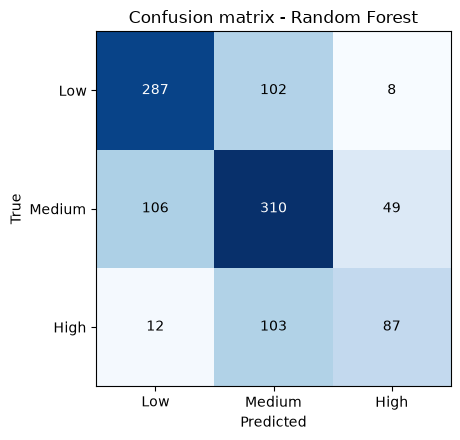

In [32]:
fig, ax = plt.subplots(figsize=(5, 4.5))
ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(3), CLASS_ORDER)
ax.set_yticks(range(3), CLASS_ORDER)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Confusion matrix - {best_name}")

for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i][j], ha="center", va="center",
                color="white" if cm[i][j] > cm.max() * 0.55 else "black")

plt.tight_layout()
plt.show()


In [33]:
total = cm.sum()
correct = cm.trace()
adjacent = cm[0][1] + cm[1][0] + cm[1][2] + cm[2][1]   # one class off
severe = cm[0][2] + cm[2][0]                            # Low predicted as High, or the reverse

print(f"correct:            {correct:4d}  ({correct / total:.1%})")
print(f"one class off:      {adjacent:4d}  ({adjacent / total:.1%})")
print(f"Low <-> High:       {severe:4d}  ({severe / total:.1%})")


correct:             684  (64.3%)
one class off:       360  (33.8%)
Low <-> High:         20  (1.9%)


Almost all of the mistakes are between neighbouring classes — Low mixed up with Medium, or Medium with High. Confusing Low with High, which is the only really severe mistake, happens in a small fraction of predictions.

That matters because the classes are ordered. A model that was guessing at random would spread its errors evenly; this one gets the direction right even when it gets the class wrong.

The weak point is High recall. The model finds fewer than half the High quality wines and calls most of the rest Medium. High is the smallest class and it sits next to the largest one, so the model plays safe.

### 7. Which measurements did the model rely on?

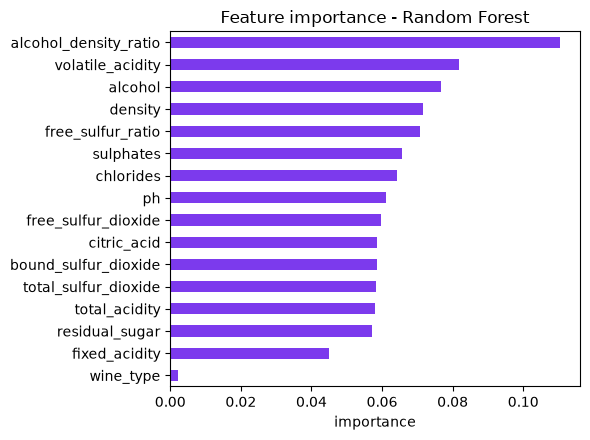

alcohol_density_ratio    0.110551
volatile_acidity         0.081778
alcohol                  0.076750
density                  0.071727
free_sulfur_ratio        0.070821
sulphates                0.065564
chlorides                0.064348
ph                       0.061014
free_sulfur_dioxide      0.059639
citric_acid              0.058589
bound_sulfur_dioxide     0.058482
total_sulfur_dioxide     0.058418
total_acidity            0.058116
residual_sugar           0.057154
fixed_acidity            0.044971
wine_type                0.002079
dtype: float64

In [34]:
importances = pd.Series(
    best_model.named_steps["model"].feature_importances_, index=FEATURES
).sort_values()

importances.plot(kind="barh", figsize=(6, 4.5), color="#7c3aed")
plt.xlabel("importance")
plt.title(f"Feature importance - {best_name}")
plt.tight_layout()
plt.show()

importances.sort_values(ascending=False)


`alcohol` (and the derived `alcohol_density_ratio`) are the most useful measurements, matching the correlation seen earlier.

`wine_type` is almost useless to the model. That is not because red and white are similar, but because they already differ in the measurements themselves — white wines have far more sulphur dioxide — so the flag adds nothing the model cannot already see.

Note that this shows what the model *uses*, not what *causes* quality. High alcohol does not make a wine good; both come from riper grapes.

## 8. Predicting a single wine

In [35]:
sample = df[FEATURES].iloc[[0]]

prediction = best_model.predict(sample)[0]
probabilities = best_model.predict_proba(sample)[0]

print("prediction:", prediction)
for cls, p in zip(best_model.classes_, probabilities):
    print(f"  {cls:7s} {p:.3f}")


prediction: Low
  High    0.000
  Low     0.970
  Medium  0.030


`predict_proba` gives the probability of each class rather than just the answer, which is what the web app displays.

In [36]:
import joblib
from pathlib import Path

MODEL_PATH = Path("../models/wine_quality_pipeline.pkl")
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(best_model, MODEL_PATH)

print(f"saved model: {MODEL_PATH.as_posix()}")


saved model: ../models/wine_quality_pipeline.pkl


## Conclusion

| | |
|---|---|
| Rows used | 5,320 (after removing 1,177 duplicates) |
| Classes | Low / Medium / High, split at the median quality score |
| Feature engineering techniques | 6 (binning, feature creation, outlier treatment, encoding, scaling, feature selection) |
| Best model | Random Forest |
| Test accuracy | about 0.65, against a 0.44 baseline |
| Cross-validated accuracy | reported above, confirming the result is stable across folds |